In [1]:
import numpy as np
import requests
from astropy.io import ascii
from astropy.io import fits
from astropy.table import Table, join, vstack
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn import preprocessing

In [3]:
# Download file
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

In [4]:
data

array([['GRB260829A', 'GRB260827A*', 'GRB260825A', ..., 'GRB910424A*',
        'GRB910423A*', 'GRB910421A*'],
       ['GRB260829256', 'GRB260827447', 'GRB260825547', ..., 'None',
        'None', 'None'],
       ['6:08:09', '10:42:59.770', '13:07:10.799', ..., '19:43:25.064',
        '19:51:15.804', '9:14:03.800'],
       ...,
       ['28.8060', '1.9200', '65.0250', ..., '3.1360', '208.5760',
        '5.6960'],
       ['True', 'True', 'True', ..., 'False', 'False', 'False'],
       ['61281.25565972', '61279.44652512', '61277.54665277', ...,
        '48370.82181787', '48369.82726625', '48367.38476620']],
      dtype='<U14')

In [9]:
names

array(['GRB_name', 'GRB_name_Fermi', 'T0', 'ra', 'decl', 'pos_error',
       'T90', 'T90_error', 'T90_start', 'fluence', 'fluence_error',
       'redshift', "'T100'", 'GBM_located', 'mjd_(T0)'], dtype='<U14')

### question we are trying to answer

- Does the distribution contain different sub-populations? How many?
- What's the threshold between the classes?
- If you try two clustering methods, do you get more or less the same?
- How do methods respond to outliers?
- What variable(s) shows the multi-modality more evidently?
- Are all GRBs equally likely to be observed? 

In [202]:
#y != -999 #mask to avoid spurious measurement

In [11]:
data_dict = dict(zip(names, data))
data_dict

{'GRB_name': array(['GRB260829A', 'GRB260827A*', 'GRB260825A', ..., 'GRB910424A*',
        'GRB910423A*', 'GRB910421A*'], dtype='<U14'),
 'GRB_name_Fermi': array(['GRB260829256', 'GRB260827447', 'GRB260825547', ..., 'None',
        'None', 'None'], dtype='<U14'),
 'T0': array(['6:08:09', '10:42:59.770', '13:07:10.799', ..., '19:43:25.064',
        '19:51:15.804', '9:14:03.800'], dtype='<U14'),
 'ra': array(['242.2600', '247.9300', '88.3500', ..., '201.3000', '193.4750',
        '270.6750'], dtype='<U14'),
 'decl': array(['-34.6200', '-53.4600', '-1.1700', ..., '-45.4167', '-8.3833',
        '24.7667'], dtype='<U14'),
 'pos_error': array(['2.584573', '3.003092', '4.386866', ..., '13.780000', '11.100000',
        '0.530000'], dtype='<U14'),
 'T90': array(['26.3690', '1.9200', '65.0250', ..., '3.1360', '208.5760',
        '5.1840'], dtype='<U14'),
 'T90_error': array(['0.9230', '0.1430', '3.0830', ..., '0.5900', '1.1180', '0.1810'],
       dtype='<U14'),
 'T90_start': array(['6:08:11.437'

In [17]:
flux = data_dict["fluence"].astype(np.float64)
#T0 = data_with_names["T0"]
print(flux)

[1.9560e-05 3.2808e-06 3.7451e-06 ... 2.4858e-08 1.6510e-07 2.6055e-06]


Text(0.5, 0, 'flux')

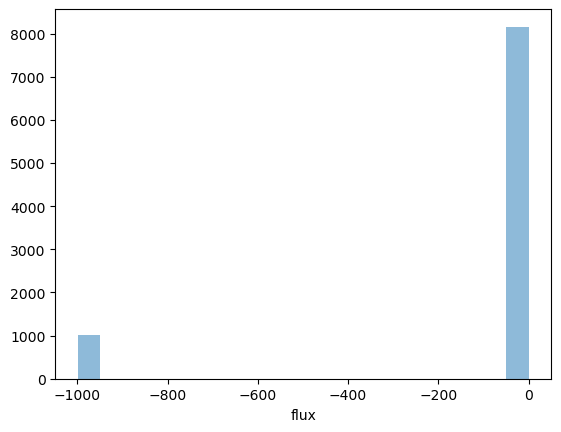

In [21]:
plt.hist(flux, bins=20, alpha=0.5) #at least we have to avoid value that are not defined well
plt.xlabel("flux")

In [207]:
flux_converted = flux.astype(np.float64)
#mask to avoid bad values
y = (flux_converted != -999) 
flux_clean = flux_converted[y]
print(len(flux_clean))
print(len(flux_converted)) #so ok the mask work well

7994
9091


In [208]:
print(y)

[False  True  True ...  True  True  True]


In [209]:
flux_converted[y]

array([2.3791e-06, 4.3871e-04, 2.8315e-07, ..., 2.4858e-08, 1.6510e-07,
       2.6055e-06])

In [232]:
T90_converted = data_with_names["T90"].astype(np.float64)
T90_clean = T90_converted[y]

Text(0.5, 0, 'flux')

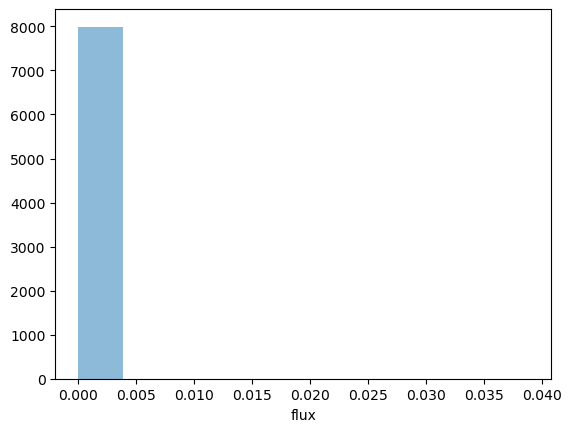

In [234]:
plt.hist(flux_clean, alpha=0.5) #clean value
#plt.xlim(-0.001,0.001)
plt.xlabel("flux")

Text(0, 0.5, 'dec')

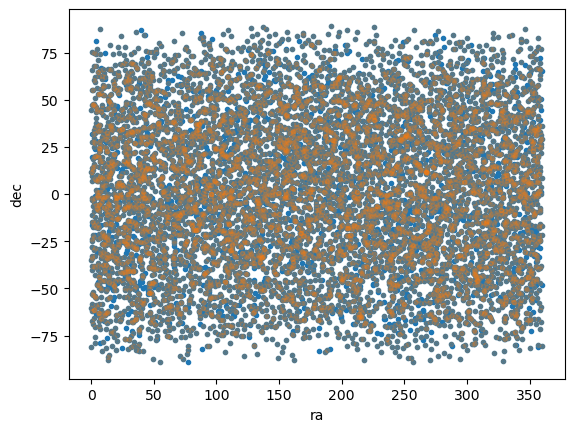

In [236]:
ra = data_with_names["ra"].astype(np.float64)
dec = data_with_names['decl'].astype(np.float64)
ra_clean = ra[y]
dec_clean = dec[y]
plt.plot(ra, dec,".")
plt.plot(ra_clean, dec_clean, ".", alpha=0.2)
plt.xlabel("ra")
plt.ylabel("dec")

Text(0, 0.5, 'log(flux)')

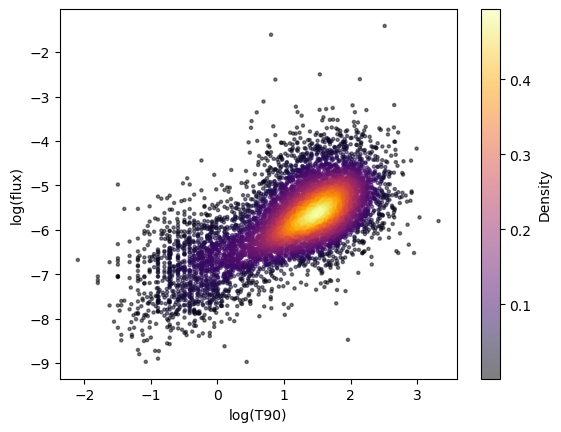

In [238]:
from scipy.stats import gaussian_kde

positive_value = (T90_clean > 0) & (flux_clean > 0)

T90 = T90_clean[positive_value]
flux = flux_clean[positive_value]

log_T90 = np.log10(T90)
log_flux = np.log10(flux)

flux_T = np.vstack([log_T90, log_flux])
z = gaussian_kde(flux_T)(flux_T)

sc= plt.scatter(log_T90,log_flux, c=z, cmap="inferno", alpha=0.5, s=5)
plt.colorbar(sc,label='Density')
plt.xlabel("log(T90)")
plt.ylabel("log(flux)")

(array([1276., 1204.,  883.,  762.,  702.,  606.,  617.,  615.,  555.,
         562.]),
 array([0.00081936, 0.05008381, 0.09934826, 0.14861271, 0.19787717,
        0.24714162, 0.29640607, 0.34567052, 0.39493498, 0.44419943,
        0.49346388]),
 <BarContainer object of 10 artists>)

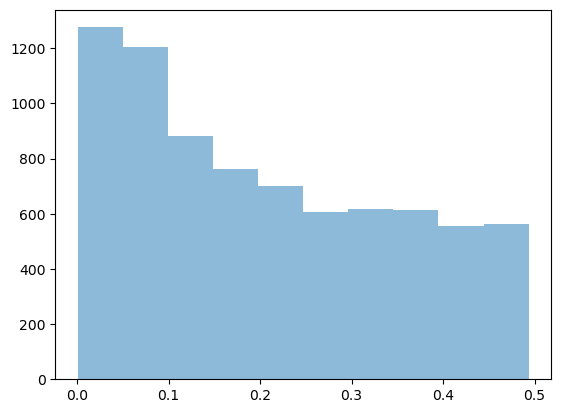

In [240]:
plt.hist(z, alpha=0.5)

[[-0.79588002 -5.6235873 ]
 [ 0.59117595 -3.35782247]
 [-0.23957752 -6.54798343]
 ...
 [ 0.49637605 -7.60453382]
 [ 2.31926433 -6.78225293]
 [ 0.71466499 -5.58410892]]


C:\Users\User\AppData\Local\Temp\ipykernel_17040\626783002.py:29: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot(x_vals, y_vals, 'k--', linewidth=2, label='Separazione KMeans', color="red")


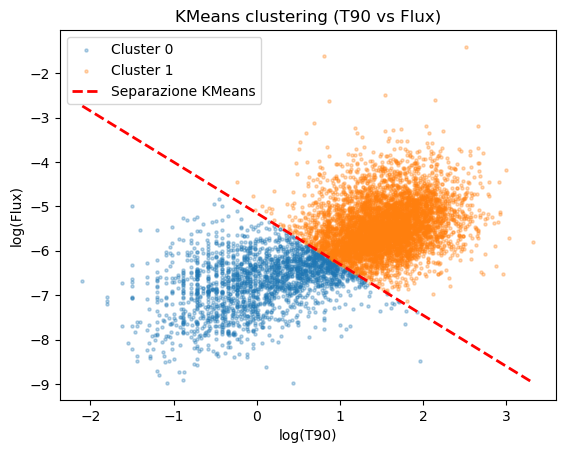

In [242]:
X = np.column_stack((log_T90, log_flux))
print(X)
clf = KMeans(n_clusters=2, n_init='auto', random_state=0)
labels = clf.fit_predict(X)

colors = ['C0', 'C1']

plt.figure()

for ii in range(2):
    plt.scatter(log_T90[labels == ii],
                log_flux[labels == ii],
                color=colors[ii],
                alpha=0.3, s=5,
                label=f'Cluster {ii}')


c0, c1 = clf.cluster_centers_ #they are two dimensional coordinate 
#calcolo della bisettrice 
w = c1 - c0
mid = (c0 + c1) / 2

a = w[0]
b = w[1]
c = -a * mid[0] - b * mid[1]

x_vals = np.linspace(log_T90.min(), log_T90.max(), 200)
y_vals = (-a * x_vals - c) / b
plt.plot(x_vals, y_vals, 'k--', linewidth=2, label='Separazione KMeans', color="red")


plt.xlabel('log(T90)')
plt.ylabel('log(Flux)')
plt.title('KMeans clustering (T90 vs Flux)')
plt.legend()

plt.show()

In [244]:
from sklearn.cluster import MeanShift       
from sklearn import preprocessing         

scaler = preprocessing.StandardScaler()       

bandwidth = 1.5                                # scale at which I search clusters 

# INITIALIZATION 
ms = MeanShift(
    bandwidth=bandwidth,       
    bin_seeding=True,         
    cluster_all=False         
)

# --- FIT ---
X_new = ms.fit(
    scaler.fit_transform(X)
    # 1. fit: calcola media e deviazione standard 
    # 2. transform: standardizza i dati
    # 3. fit MeanShift: trova i massimi di densità (cluster)
)
labels_unique = np.unique(ms.labels_)
n_clusters = len(labels_unique[labels_unique >= 0])
print(labels_unique)
print(bandwidth)
print("number of estimated clusters :", n_clusters)

[-1  0  1]
1.5
number of estimated clusters : 2


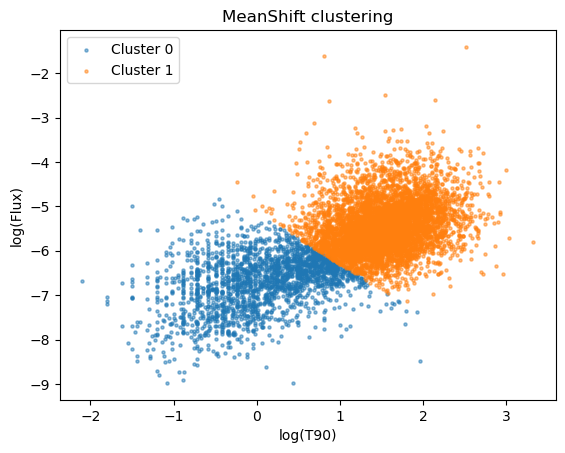

In [216]:
for ii in range(2):
    mask = labels == ii
    
    plt.scatter(log_T90[mask],
                log_flux[mask],
                alpha=0.5,
                s=5,
                label=f'Cluster {ii}')

plt.xlabel('log(T90)')
plt.ylabel('log(Flux)')
plt.title('MeanShift clustering')
plt.legend()

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_17040\3583213120.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot(x_vals, y_vals, 'k--', linewidth=2, label='Separazione KMeans', color="red")


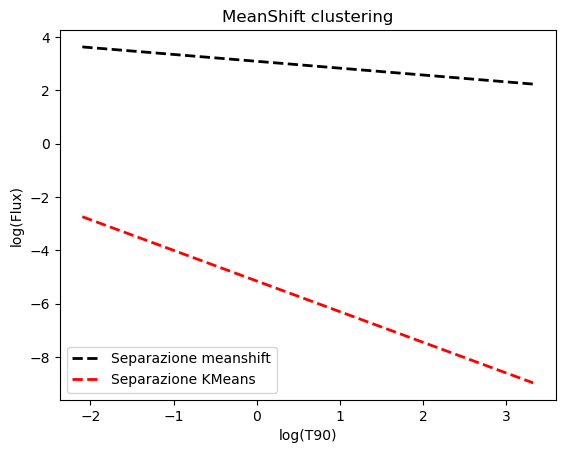

In [246]:
centers_ms = ms.cluster_centers_
c0_ms, c1_ms = centers_ms[:2]

# --- retta di separazione (perpendicolare tra centroidi) ---
w_ms = c1_ms - c0_ms
mid_ms = (c0_ms + c1_ms) / 2

a_ms = w_ms[0]
b_ms = w_ms[1]
c_ms = -a_ms * mid_ms[0] - b_ms * mid_ms[1]

# --- costruzione linea ---
x_vals_ms = np.linspace(log_T90.min(), log_T90.max(), 200)
y_vals_ms = (-a_ms * x_vals_ms - c_ms) / b_ms

plt.plot(x_vals_ms, y_vals_ms, 'k--', linewidth=2, label='Separazione meanshift')
plt.plot(x_vals, y_vals, 'k--', linewidth=2, label='Separazione KMeans', color="red")
plt.xlabel('log(T90)')
plt.ylabel('log(Flux)')
plt.title('MeanShift clustering')
plt.legend()

plt.show()
#maybe this could be an info for the role of outliers

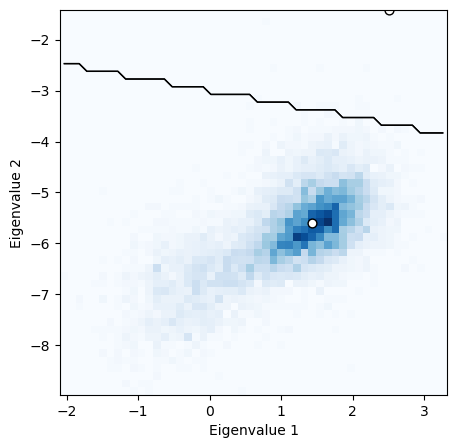

In [248]:
# Make some plots
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot()

# Compute a 2D histogram  of the input
H, xedges, yedges = np.histogram2d(X[:,0], X[:,1], 50)

# plot density
ax.imshow(H.T, origin='lower', interpolation='nearest', aspect='auto',
          extent=[xedges[0], xedges[-1],
                  yedges[0], yedges[-1]],
          cmap='Blues')

# plot cluster centers
cluster_centers = scaler.inverse_transform(ms.cluster_centers_)
ax.scatter(cluster_centers[:, 0], cluster_centers[:, 1],
           s=40, c='w', edgecolors='k')

# plot cluster boundaries
x_centers = 0.5 * (xedges[1:] + xedges[:-1])
y_centers = 0.5 * (yedges[1:] + yedges[:-1])

Xgrid = np.meshgrid(x_centers, y_centers)
Xgrid = np.array(Xgrid).reshape((2, 50 * 50)).T

H = ms.predict(scaler.transform(Xgrid)).reshape((50, 50))

for i in range(n_clusters):
    Hcp = H.copy()
    flag = (Hcp == i)
    Hcp[flag] = 1
    Hcp[~flag] = 0

    ax.contour(x_centers, y_centers, Hcp, [-0.5, 0.5],
               linewidths=1, colors='k')
 
    H = ms.predict(scaler.transform(Xgrid)).reshape((50, 50))
    
ax.set_xlim(xedges[0], xedges[-1])
ax.set_ylim(yedges[0], yedges[-1])

ax.set_xlabel('Eigenvalue 1')
ax.set_ylabel('Eigenvalue 2')

plt.show()

Text(0.5, 0, 'log(flux)')

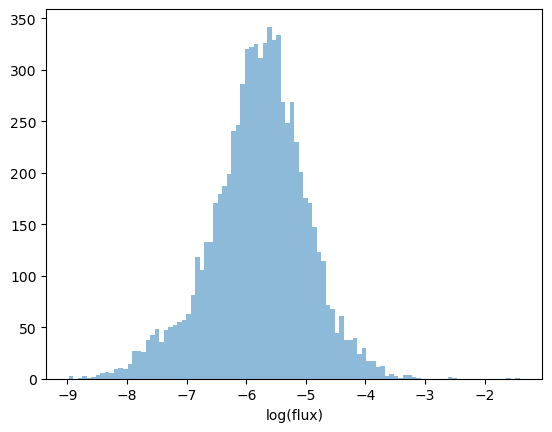

In [250]:
plt.hist(log_flux, bins=100, alpha=0.5)
plt.xlabel("log(flux)")

744


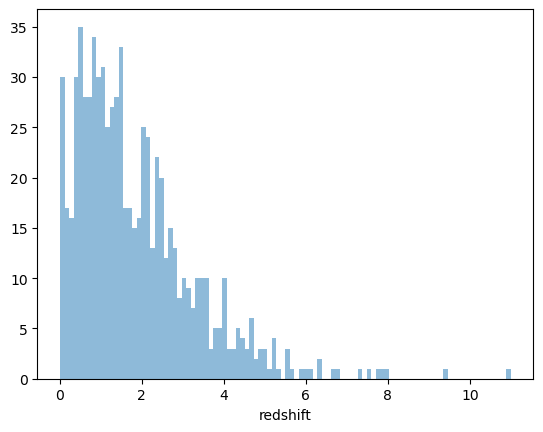

In [251]:
z_converted = data_with_names["redshift"].astype(np.float64)
mask_z = (z_converted != -999) #maschera sul redshift non coincide con quella sul flusso
z_clean = z_converted[mask_z]
plt.hist(z_clean, bins=100, alpha=0.5)
plt.xlabel("redshift") 
print(len(z_clean)) #you also have less galaxy

744


C:\Users\User\AppData\Local\Temp\ipykernel_17040\3606504092.py:3: RuntimeWarning: invalid value encountered in log10
  plt.scatter(np.log10(T90_converted),np.log10(z_converted), s=10,alpha=0.5, color="red") #check if it is correct


Text(0, 0.5, 'z')

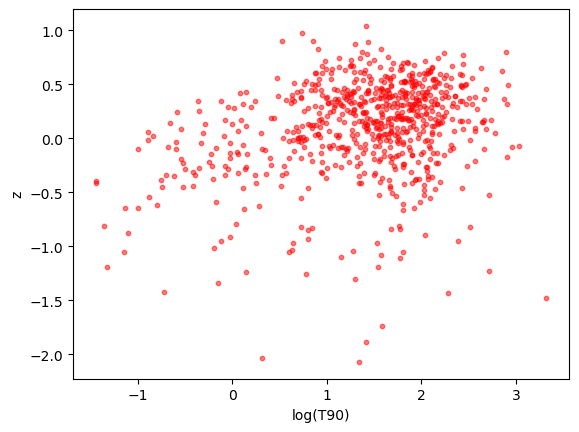

In [261]:
T90_maskz = T90_converted[mask_z]
print(len(T90_maskz))
plt.scatter(np.log10(T90_converted),np.log10(z_converted), s=10,alpha=0.5, color="red") #check if it is correct 
plt.xlabel("log(T90)")
plt.ylabel("z")

(-1100.0, 1100.0)

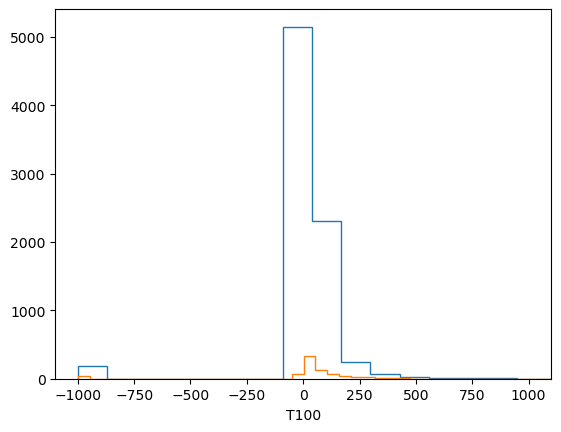

In [285]:
T100_converted = data_with_names["\'T100\'"].astype(np.float64)
T100_clean = T100_converted[y]
T100_maskz = T100_converted[mask_z]
#print(len(T100_converted))
plt.hist(T100_clean, bins=100, histtype="step")
plt.hist(T100_maskz, bins=100, histtype="step")
plt.xlabel("T100")
plt.xlim(-1100,1100)

In [287]:
#new mask only for T100
mask_T100 = (T100_converted != -999) 

In [289]:
T100_right_mask = T100_converted[mask_T100]

(-10.0, 700.0)

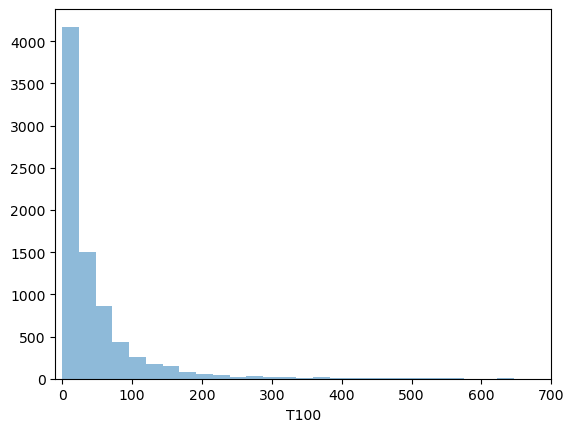

In [303]:
plt.hist(T100_right_mask, bins=500,alpha=0.5)
plt.xlabel("T100")
plt.xlim(-10, 700)